In [1]:
# Periodic MPS Cost Analysis - Heatmaps for Different Tensor Types
# This notebook generates heatmaps for diagexp, spikes, and uniform1 tensor types
# across three metrics: relative error (gmean), variance of log(rel_error), and geometric std dev

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import pandas as pd
import time
import sys
import os
from functools import partial

# add the parent directory to the path to import from src and tests
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# import the algorithm components
from src.algorithm import (
    TensorNetwork, 
    run_multiple_chains,
)

# import MPS builders from test file
from tests.test_periodic_mps import (
    build_periodic_mps,
    exact_contract_periodic_mps,
)


In [2]:
# helper functions for geometric statistics on relative errors
EPS = 1e-12

def gmean_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    if len(x) == 0 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    return float(np.exp(np.mean(log_x)))

def gvar_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    if len(x) < 2 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    if np.allclose(log_x, log_x[0]):
        return 0.0
    return float(np.var(log_x, ddof=1))

def gstd_series(s):
    """
    Compute true geometric standard deviation: GSD(ε) = exp(Std(log ε))
    Returns ≥ 1, where 1 means no multiplicative spread.
    """
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    if len(x) < 2 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    std_log = np.std(log_x, ddof=1)
    if np.allclose(std_log, 0.0):
        return 1.0
    return float(np.exp(std_log))


In [3]:
# experiment runner for periodic MPS

def create_mps_tensor_network(tensor_type="gaussian", n_sites=16, dim=3, seed=42,
                               eps=1e-6, alpha=0.6, spike_factor=10.0, jitter=0.1):
    """
    Create a periodic MPS tensor network with specified tensor type.
    
    tensor_type options:
      - "gaussian"   (N(1, 0.1), clipped >= eps)
      - "uniform1"   (U[1-jitter, 1+jitter], clipped >= eps)
      - "diagexp"    (diagonal exp(-alpha*k), off-diagonal eps)
      - "spikes"     (uniform1 + diagonal * spike_factor)
    """
    G, tensors = build_periodic_mps(
        n_sites=n_sites,
        dim=dim,
        tensor_type=tensor_type,
        seed=seed,
        eps=eps,
        alpha=alpha,
        spike_factor=spike_factor,
        jitter=jitter,
    )
    
    Z_true = exact_contract_periodic_mps(tensors, n_sites, dim)
    tn = TensorNetwork(G, tensors)
    
    return tn, Z_true


def run_ais_experiment(tn, A, B, C, seed=None, verbose=False, return_time=True):
    if seed is not None:
        np.random.seed(int(seed))
    
    # logspace beta schedule
    betas = 1.0 - np.logspace(0, np.log10(1e-6), A)
    betas[0] = 0.0
    betas[-1] = 1.0
    
    start_time = time.time() if return_time else None
    
    Z_est, Z_std = run_multiple_chains(
        tn, betas, 
        iters=C, 
        burns=min(C//10, C-1),
        n_chains=B, 
        verbose=verbose,
    )
    
    end_time = time.time() if return_time else None
    wall_time = (end_time - start_time) if return_time else None
    
    return {
        'Z_est': Z_est,
        'Z_std': Z_std, 
        'time_seconds': wall_time,
        'A': A, 'B': B, 'C': C,
        'N': A * B * C,
        'seed': seed
    }


def compute_relative_error(Z_est, Z_true):
    if Z_true is None:
        return np.nan
    return abs(Z_est - Z_true) / abs(Z_true)


def generate_mps_experiment_data(
    tensor_type,
    n_sites,
    dim,
    N_values,
    A_range,
    B_range,
    seeds,
    eps=1e-6,
    alpha=0.6,
    spike_factor=10.0,
    jitter=0.1,
    verbose=True
):
    """
    Generate experiment data for periodic MPS with specified tensor type.
    """
    results = []
    total = len(N_values) * len(A_range) * len(B_range) * len(seeds)
    count = 0

    # create the base tensor network (fixed seed for network structure)
    tn, Z_true = create_mps_tensor_network(
        tensor_type=tensor_type,
        n_sites=n_sites,
        dim=dim,
        seed=42,  # fixed seed for network
        eps=eps,
        alpha=alpha,
        spike_factor=spike_factor,
        jitter=jitter,
    )
    
    if verbose:
        print(f"[info] tensor type: {tensor_type}, n_sites={n_sites}, dim={dim}")
        print(f"[info] Z_true = {Z_true:.6e}")

    for N in N_values:
        for A in A_range:
            for B in B_range:
                if N % (A * B) != 0:
                    continue
                C = N // (A * B)
                if C < 1:
                    continue

                for seed in seeds:
                    count += 1
                    if verbose and count % 10 == 0:
                        print(f"[info] progress: {count}/{total} | A={A}, B={B}, C={C}, seed={seed}")

                    out = run_ais_experiment(tn, A, B, C, seed=seed, verbose=False)
                    rel_err = compute_relative_error(out['Z_est'], Z_true)

                    results.append({
                        'tensor_type': tensor_type,
                        'n_sites': n_sites,
                        'dim': dim,
                        'N': N, 'A': A, 'B': B, 'C': C, 'seed': seed,
                        'Z_est': out['Z_est'],
                        'Z_std': out['Z_std'],
                        'Z_true': Z_true,
                        'rel_error': rel_err,
                        'time_seconds': out['time_seconds']
                    })

    return pd.DataFrame(results)


In [4]:
# heatmap plotting functions

def plot_cost_heatmap(df, N_value, tensor_type, metric='rel_error', aggregation='gmean', save_path=None):
    data = df[(df['N'] == N_value) & (df['tensor_type'] == tensor_type)].copy()
    
    if data.empty:
        print(f"[error] no data for N={N_value}, tensor_type={tensor_type}")
        return
    
    if aggregation == 'mean':
        agg_data = data.groupby(['A', 'B'])[metric].mean().reset_index()
    elif aggregation == 'median':
        agg_data = data.groupby(['A', 'B'])[metric].median().reset_index()
    elif aggregation == 'min':
        agg_data = data.groupby(['A', 'B'])[metric].min().reset_index()
    elif aggregation == 'gmean': 
        agg = data.groupby(['A','B'])[metric].apply(gmean_series)
        agg_data = agg.reset_index(name=metric)
    else:
        raise ValueError(f"Unknown aggregation: {aggregation}")

    pivot = agg_data.pivot(index='A', columns='B', values=metric)
    C_pivot = data.groupby(['A', 'B'])['C'].first().reset_index().pivot(index='A', columns='B', values='C')
    C_pivot = C_pivot.fillna(0).astype(int)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.heatmap(pivot, annot=True, fmt='.2e' if metric == 'rel_error' else '.2f', 
                cmap='viridis', ax=ax1)
    ax1.set_title(f'{tensor_type.upper()} - {metric.replace("_", " ").title()} ({aggregation})\nN = {N_value}')
    ax1.set_xlabel('B (number of chains)')
    ax1.set_ylabel('A (beta ladder length)')
    
    sns.heatmap(C_pivot, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title(f'Corresponding C values\n(iterations per chain per beta)')
    ax2.set_xlabel('B (number of chains)')
    ax2.set_ylabel('A (beta ladder length)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[saved] {save_path}")
    
    plt.show()


def plot_variance_heatmap(df, N_value, tensor_type, metric='rel_error', mode='logvar', save_path=None):
    data = df[(df['N'] == N_value) & (df['tensor_type'] == tensor_type)].copy()
    if data.empty:
        print(f"[error] no data for N={N_value}, tensor_type={tensor_type}")
        return
    
    if mode == 'logvar':
        agg = data.groupby(['A','B'])[metric].apply(gvar_series).reset_index(name='logvar')
        values = agg.pivot(index='A', columns='B', values='logvar')
        title = f'{tensor_type.upper()} - Variance of log(Rel Error)'
        fmt = '.2e'
        cmap = 'magma'
    elif mode == 'gstd':
        agg = data.groupby(['A','B'])[metric].apply(gstd_series).reset_index(name='gstd')
        values = agg.pivot(index='A', columns='B', values='gstd')
        title = f'{tensor_type.upper()} - Geometric Std Dev of Rel Error'
        fmt = '.2f'
        cmap = 'magma_r'
    else:
        raise ValueError(f"Unknown mode: {mode}")
    
    C_pivot = data.groupby(['A', 'B'])['C'].first().reset_index().pivot(index='A', columns='B', values='C')
    C_pivot = C_pivot.fillna(0).astype(int)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(values, annot=True, fmt=fmt, cmap=cmap, ax=ax1)
    ax1.set_title(f'{title}\nN = {N_value}')
    ax1.set_xlabel('B (number of chains)')
    ax1.set_ylabel('A (beta ladder length)')

    sns.heatmap(C_pivot, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Corresponding C values\n(iterations per chain per beta)')
    ax2.set_xlabel('B (number of chains)')
    ax2.set_ylabel('A (beta ladder length)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[saved] {save_path}")
    
    plt.show()


In [5]:
# Configuration for periodic MPS experiments

# MPS parameters
N_SITES = 16
DIM = 3

# tensor types to test
TENSOR_TYPES = ['diagexp', 'spikes', 'uniform1']

# model-specific parameters
ALPHA = 0.6          # for diagexp
SPIKE_FACTOR = 10.0  # for spikes
JITTER = 0.1         # for uniform1 and spikes

# AIS budget
N_values = [100000]

# parameter ranges
A_range = [20, 50, 100, 200, 500]   # beta ladder lengths
B_range = [5, 10, 20, 25, 50, 100, 200]  # number of chains

# trial seeds
seeds = [11, 23, 42, 77, 101]

print(f"[config] Periodic MPS: n_sites={N_SITES}, dim={DIM}")
print(f"[config] Tensor types: {TENSOR_TYPES}")
print(f"[config] N = {N_values}")
print(f"[config] A (beta steps) = {A_range}")
print(f"[config] B (chains) = {B_range}")
print(f"[config] Seeds: {seeds}")

# show valid combinations
print(f"\n[info] valid (A,B,C) combinations for N={N_values[0]}:")
valid_combinations = []
for A in A_range:
    for B in B_range:
        if N_values[0] % (A * B) == 0:
            C = N_values[0] // (A * B)
            if C >= 1:
                valid_combinations.append((A, B, C))
                print(f"  A={A:3d}, B={B:3d}, C={C:4d}")

print(f"\n[info] {len(valid_combinations)} combinations x {len(seeds)} seeds x {len(TENSOR_TYPES)} types = {len(valid_combinations) * len(seeds) * len(TENSOR_TYPES)} total experiments")


[config] Periodic MPS: n_sites=16, dim=3
[config] Tensor types: ['diagexp', 'spikes', 'uniform1']
[config] N = [100000]
[config] A (beta steps) = [20, 50, 100, 200, 500]
[config] B (chains) = [5, 10, 20, 25, 50, 100, 200]
[config] Seeds: [11, 23, 42, 77, 101]

[info] valid (A,B,C) combinations for N=100000:
  A= 20, B=  5, C=1000
  A= 20, B= 10, C= 500
  A= 20, B= 20, C= 250
  A= 20, B= 25, C= 200
  A= 20, B= 50, C= 100
  A= 20, B=100, C=  50
  A= 20, B=200, C=  25
  A= 50, B=  5, C= 400
  A= 50, B= 10, C= 200
  A= 50, B= 20, C= 100
  A= 50, B= 25, C=  80
  A= 50, B= 50, C=  40
  A= 50, B=100, C=  20
  A= 50, B=200, C=  10
  A=100, B=  5, C= 200
  A=100, B= 10, C= 100
  A=100, B= 20, C=  50
  A=100, B= 25, C=  40
  A=100, B= 50, C=  20
  A=100, B=100, C=  10
  A=100, B=200, C=   5
  A=200, B=  5, C= 100
  A=200, B= 10, C=  50
  A=200, B= 20, C=  25
  A=200, B= 25, C=  20
  A=200, B= 50, C=  10
  A=200, B=100, C=   5
  A=500, B=  5, C=  40
  A=500, B= 10, C=  20
  A=500, B= 20, C=  10
 

In [6]:
# Run experiments for all tensor types

all_results = []
start_time = time.time()

for tensor_type in TENSOR_TYPES:
    print(f"\n{'='*60}")
    print(f"[running] tensor_type = {tensor_type}")
    print(f"{'='*60}")
    
    df = generate_mps_experiment_data(
        tensor_type=tensor_type,
        n_sites=N_SITES,
        dim=DIM,
        N_values=N_values,
        A_range=A_range,
        B_range=B_range,
        seeds=seeds,
        alpha=ALPHA,
        spike_factor=SPIKE_FACTOR,
        jitter=JITTER,
        verbose=True
    )
    all_results.append(df)
    
    # quick stats
    print(f"\n[summary] {tensor_type}:")
    print(f"  rel_error range: {df['rel_error'].min():.2e} to {df['rel_error'].max():.2e}")
    print(f"  geom mean: {gmean_series(df['rel_error'].dropna()):.2e}")

# combine all results
results_df = pd.concat(all_results, ignore_index=True)

end_time = time.time()
print(f"\n{'='*60}")
print(f"[done] all experiments completed in {end_time - start_time:.1f} seconds")
print(f"[info] total data points: {len(results_df)}")

# save combined results
results_df.to_csv('mps_costs_N100k.csv', index=False)
print(f"[saved] mps_costs_N100k.csv")



[running] tensor_type = diagexp
[info] tensor type: diagexp, n_sites=16, dim=3
[info] Z_true = 1.000068e+00
[info] progress: 10/175 | A=20, B=10, C=500, seed=101
[info] progress: 20/175 | A=20, B=25, C=200, seed=101
[info] progress: 30/175 | A=20, B=100, C=50, seed=101
[info] progress: 40/175 | A=50, B=5, C=400, seed=101
[info] progress: 50/175 | A=50, B=20, C=100, seed=101
[info] progress: 60/175 | A=50, B=50, C=40, seed=101
[info] progress: 70/175 | A=50, B=200, C=10, seed=101
[info] progress: 80/175 | A=100, B=10, C=100, seed=101
[info] progress: 90/175 | A=100, B=25, C=40, seed=101
[info] progress: 100/175 | A=100, B=100, C=10, seed=101
[info] progress: 110/175 | A=200, B=5, C=100, seed=101
[info] progress: 120/175 | A=200, B=20, C=25, seed=101
[info] progress: 130/175 | A=200, B=50, C=10, seed=101
[info] progress: 140/175 | A=500, B=5, C=40, seed=101
[info] progress: 150/175 | A=500, B=20, C=10, seed=101
[info] progress: 160/175 | A=500, B=50, C=4, seed=101
[info] progress: 170/1

[saved] ../plots/heatmaps/mps_diagexp_gmean_rel_error.png


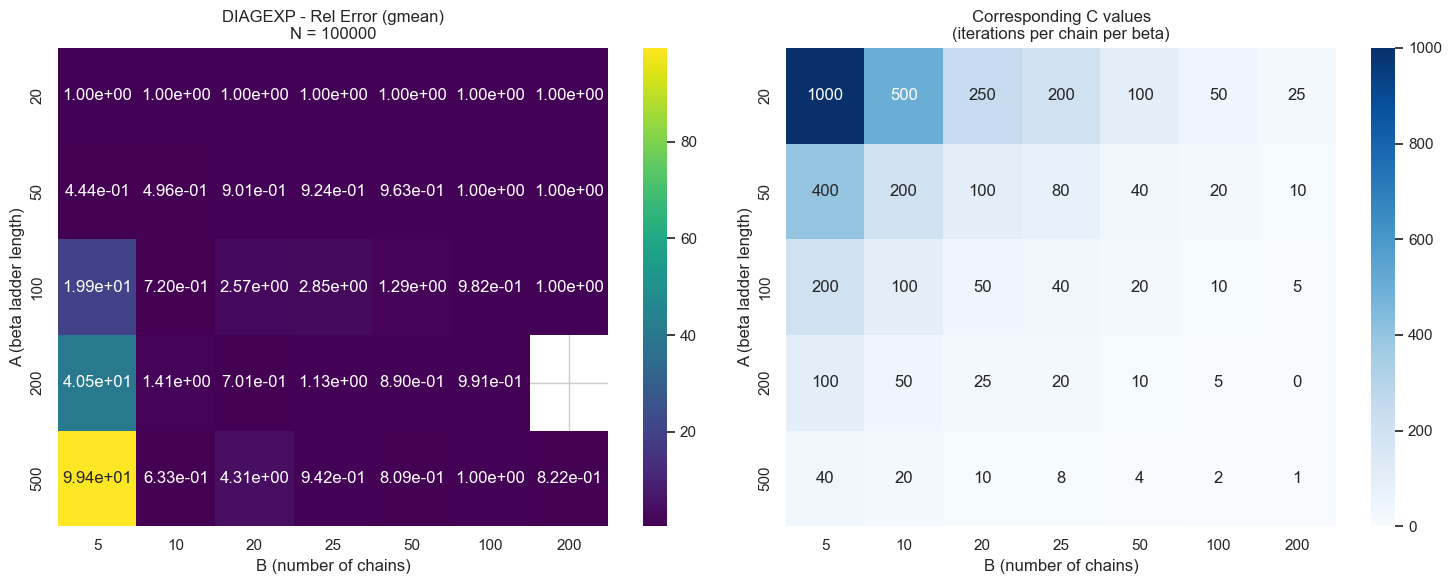

In [7]:
# DIAGEXP - Geometric Mean Relative Error
plot_cost_heatmap(results_df, N_value=100000, tensor_type='diagexp', 
                  metric='rel_error', aggregation='gmean',
                  save_path='../plots/heatmaps/mps_diagexp_gmean_rel_error.png')


[saved] ../plots/heatmaps/mps_diagexp_var_log_rel_error.png


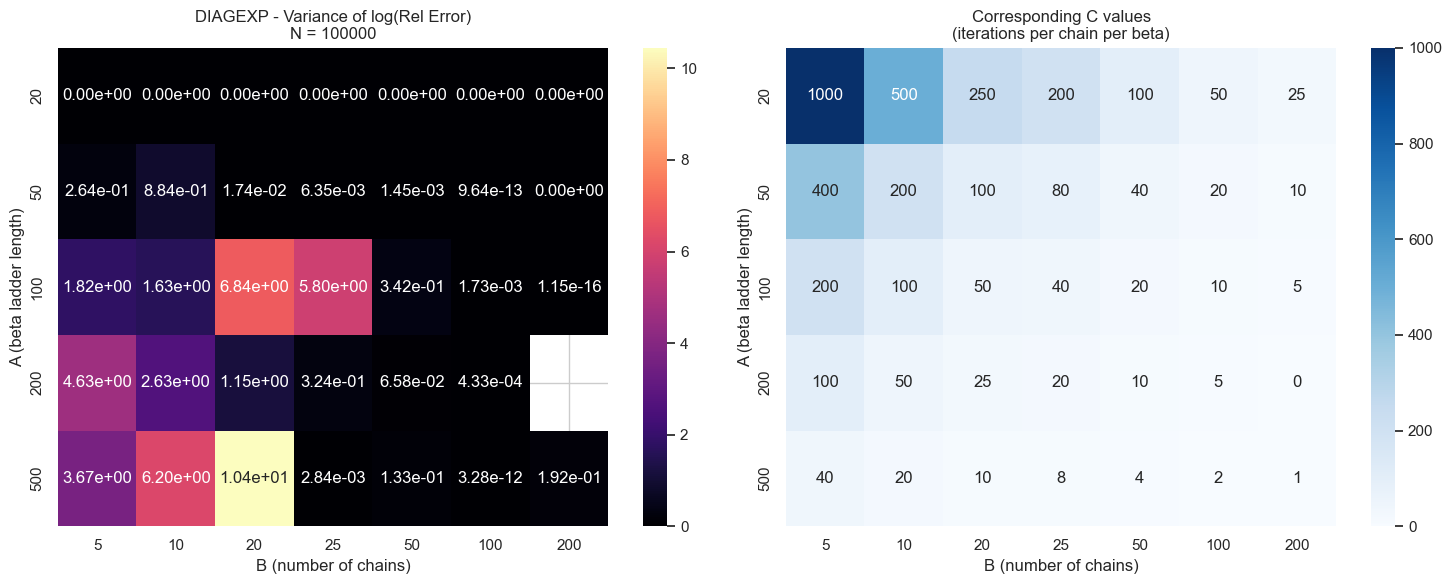

In [8]:
# DIAGEXP - Variance of log(Rel Error)
plot_variance_heatmap(results_df, N_value=100000, tensor_type='diagexp',
                      metric='rel_error', mode='logvar',
                      save_path='../plots/heatmaps/mps_diagexp_var_log_rel_error.png')


[saved] ../plots/heatmaps/mps_diagexp_gstd_rel_error.png


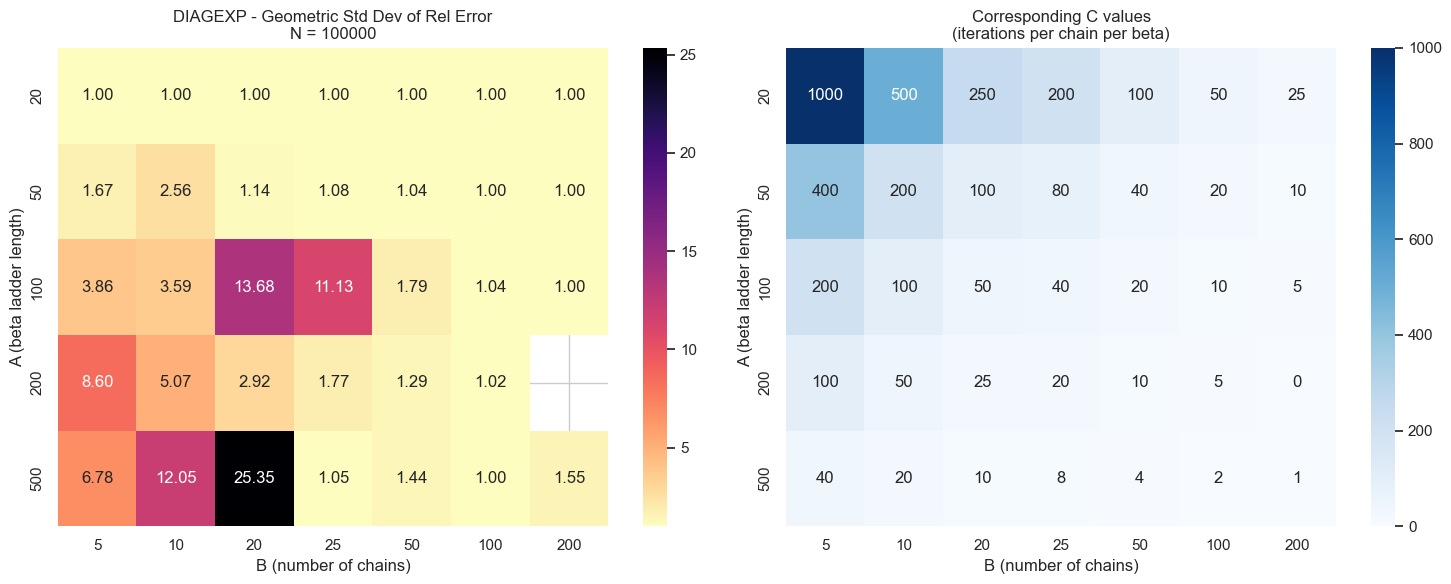

In [9]:
# DIAGEXP - Geometric Std Dev
plot_variance_heatmap(results_df, N_value=100000, tensor_type='diagexp',
                      metric='rel_error', mode='gstd',
                      save_path='../plots/heatmaps/mps_diagexp_gstd_rel_error.png')


[saved] ../plots/heatmaps/mps_spikes_var_log_rel_error.png


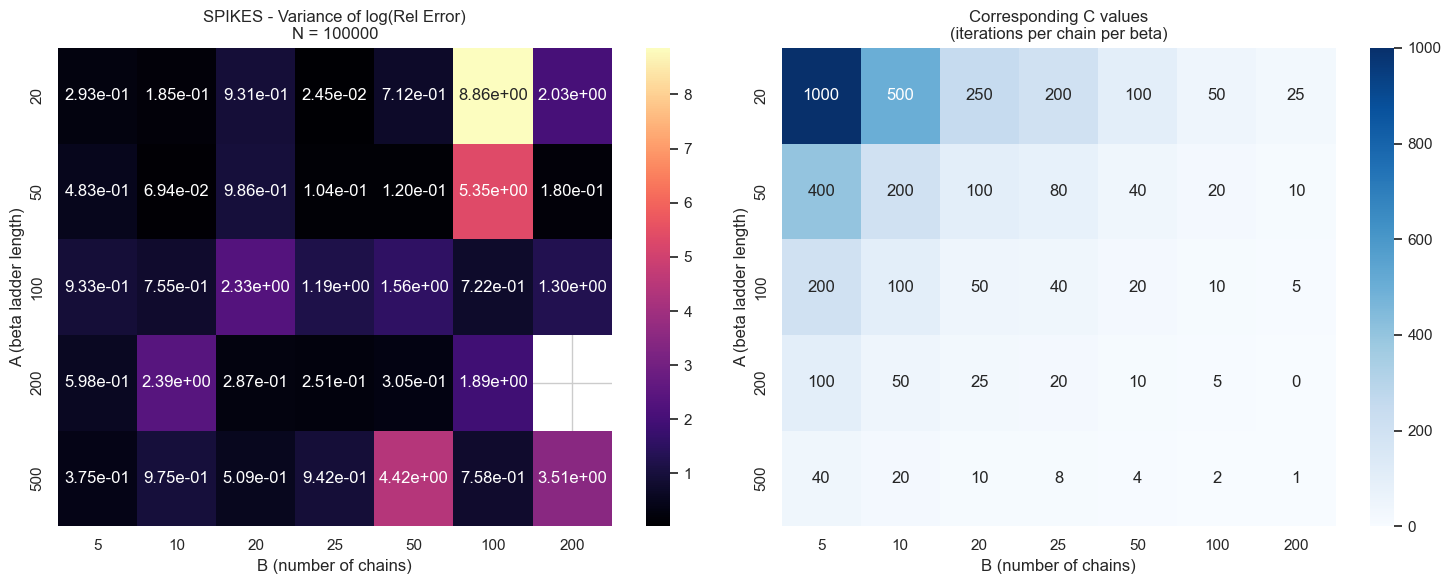

In [10]:
# SPIKES - Variance of log(Rel Error)
plot_variance_heatmap(results_df, N_value=100000, tensor_type='spikes',
                      metric='rel_error', mode='logvar',
                      save_path='../plots/heatmaps/mps_spikes_var_log_rel_error.png')


[saved] ../plots/heatmaps/mps_spikes_gstd_rel_error.png


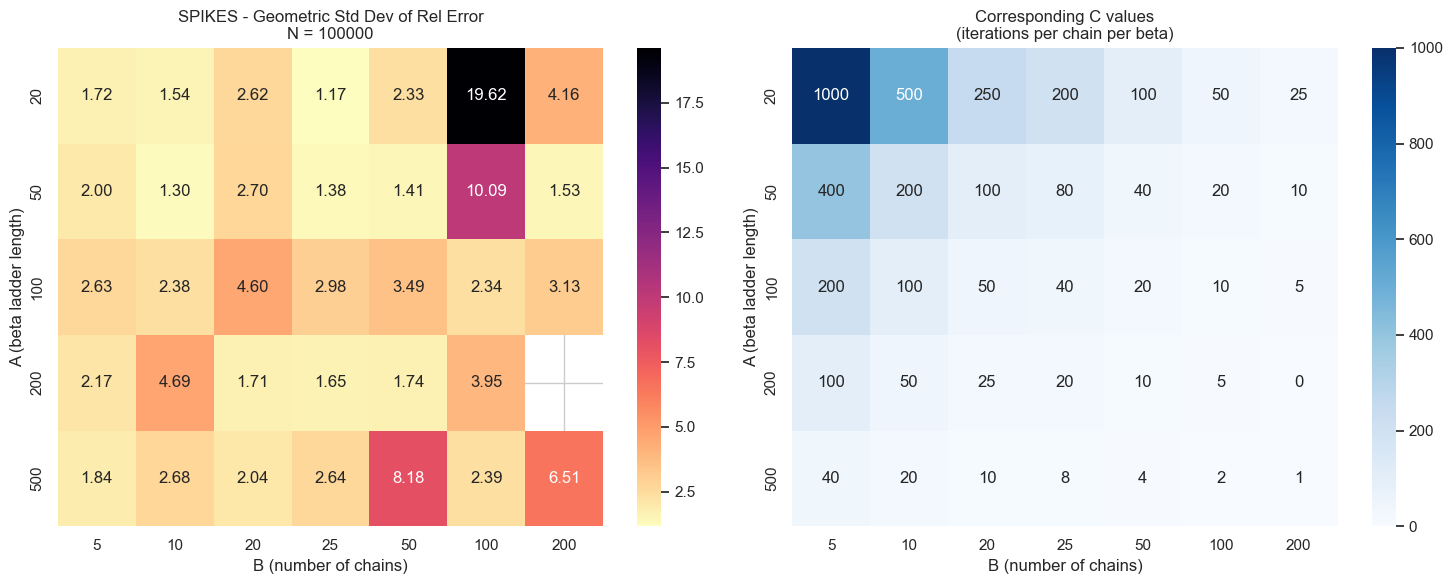

In [11]:
# SPIKES - Geometric Std Dev
plot_variance_heatmap(results_df, N_value=100000, tensor_type='spikes',
                      metric='rel_error', mode='gstd',
                      save_path='../plots/heatmaps/mps_spikes_gstd_rel_error.png')


[saved] ../plots/heatmaps/mps_uniform1_gmean_rel_error.png


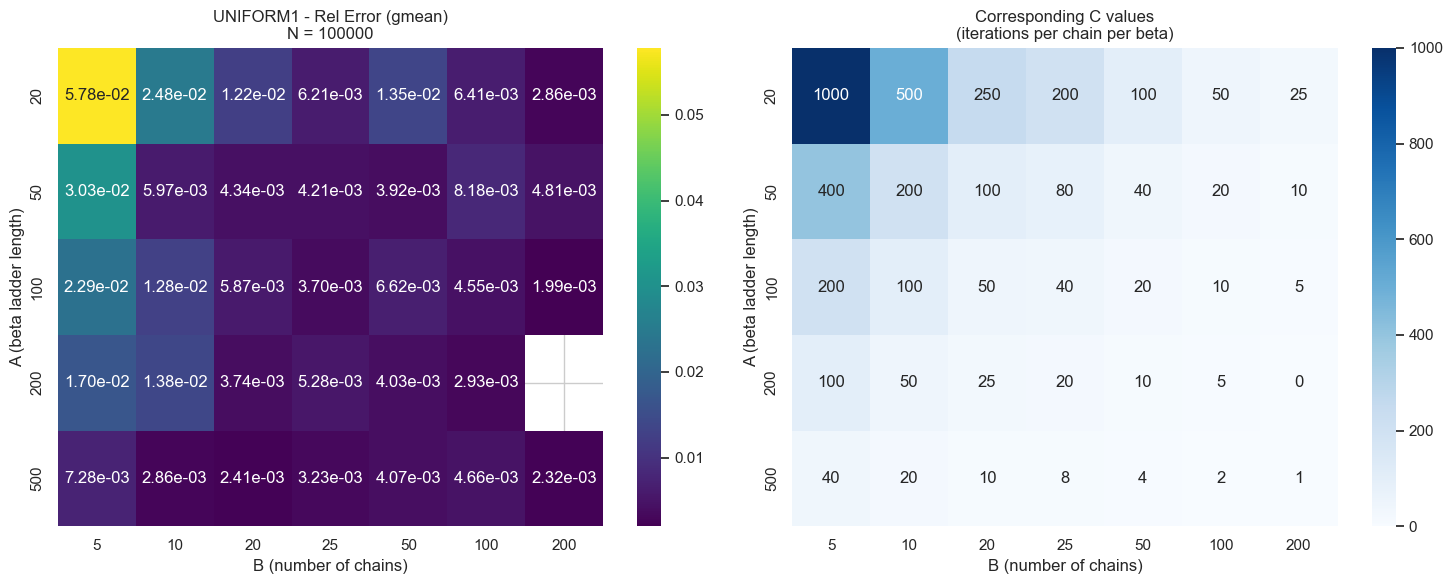

In [12]:
# UNIFORM1 - Geometric Mean Relative Error
plot_cost_heatmap(results_df, N_value=100000, tensor_type='uniform1', 
                  metric='rel_error', aggregation='gmean',
                  save_path='../plots/heatmaps/mps_uniform1_gmean_rel_error.png')


[saved] ../plots/heatmaps/mps_uniform1_var_log_rel_error.png


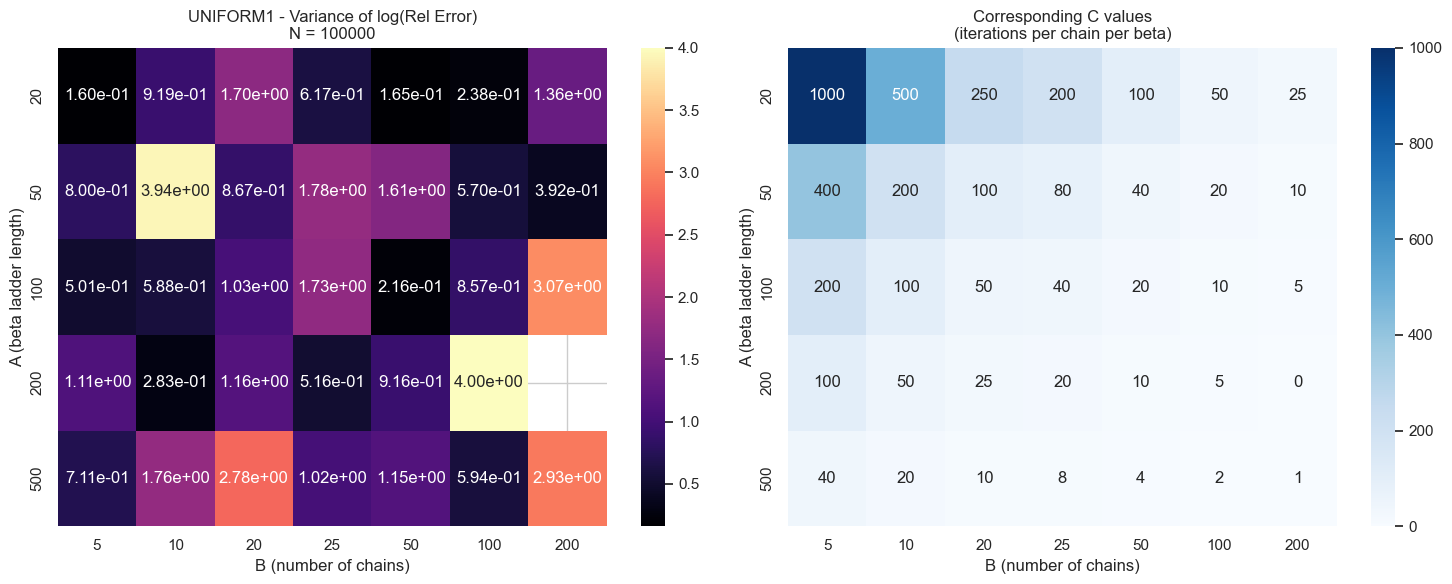

In [13]:
# UNIFORM1 - Variance of log(Rel Error)
plot_variance_heatmap(results_df, N_value=100000, tensor_type='uniform1',
                      metric='rel_error', mode='logvar',
                      save_path='../plots/heatmaps/mps_uniform1_var_log_rel_error.png')


[saved] ../plots/heatmaps/mps_uniform1_gstd_rel_error.png


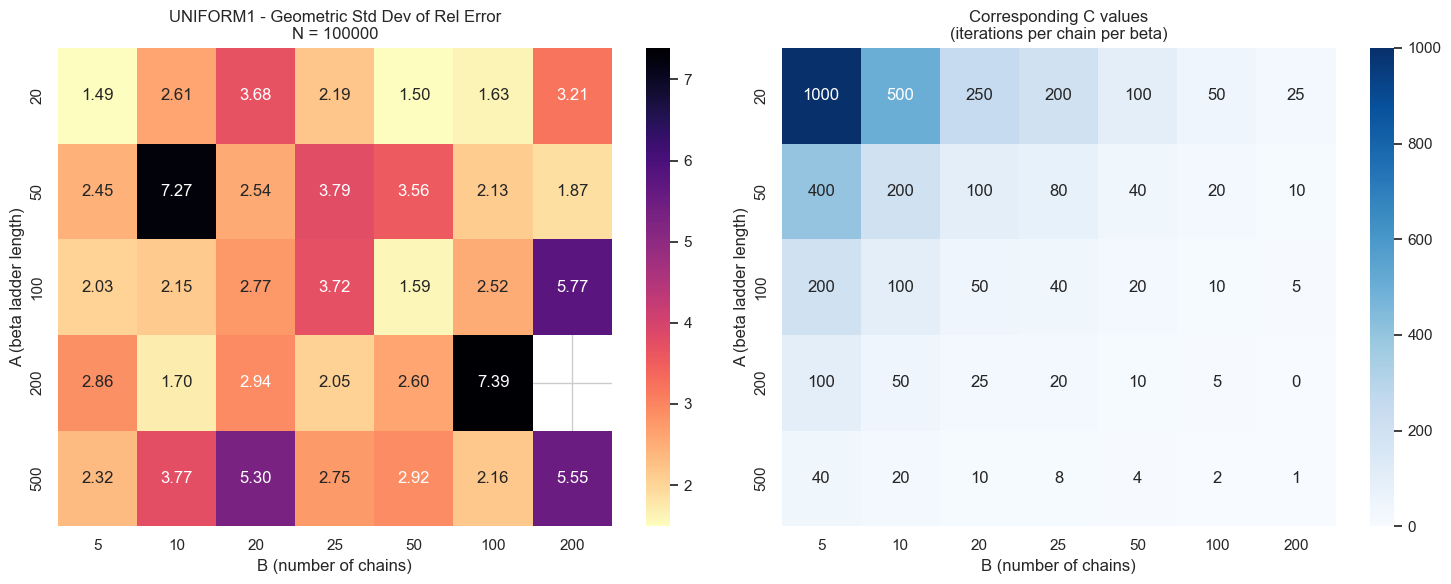

In [14]:
# UNIFORM1 - Geometric Std Dev
plot_variance_heatmap(results_df, N_value=100000, tensor_type='uniform1',
                      metric='rel_error', mode='gstd',
                      save_path='../plots/heatmaps/mps_uniform1_gstd_rel_error.png')


In [15]:
# Summary statistics across tensor types
print("\n" + "="*70)
print("SUMMARY: Periodic MPS Cost Analysis")
print(f"n_sites={N_SITES}, dim={DIM}, N={N_values[0]}")
print("="*70)

for tensor_type in TENSOR_TYPES:
    subset = results_df[results_df['tensor_type'] == tensor_type]
    Z_true = subset['Z_true'].iloc[0]
    
    print(f"\n[{tensor_type.upper()}]")
    print(f"  Z_true: {Z_true:.6e}")
    print(f"  rel_error range: {subset['rel_error'].min():.2e} to {subset['rel_error'].max():.2e}")
    print(f"  geom mean rel_error: {gmean_series(subset['rel_error'].dropna()):.2e}")
    print(f"  median rel_error: {subset['rel_error'].median():.2e}")
    
    # best configuration
    best_idx = subset.groupby(['A', 'B'])['rel_error'].apply(gmean_series).idxmin()
    best_A, best_B = best_idx
    best_C = N_values[0] // (best_A * best_B)
    best_err = subset.groupby(['A', 'B'])['rel_error'].apply(gmean_series).min()
    print(f"  best (A,B,C): ({best_A}, {best_B}, {best_C}) -> gmean_err = {best_err:.2e}")



SUMMARY: Periodic MPS Cost Analysis
n_sites=16, dim=3, N=100000

[DIAGEXP]
  Z_true: 1.000068e+00
  rel_error range: 1.12e-02 to 6.71e+02
  geom mean rel_error: 1.42e+00
  median rel_error: 1.00e+00
  best (A,B,C): (50, 5, 400) -> gmean_err = 4.44e-01

[SPIKES]
  Z_true: 1.682967e+17
  rel_error range: 6.38e-04 to 6.22e+00
  geom mean rel_error: 2.14e-01
  median rel_error: 3.03e-01
  best (A,B,C): (500, 50, 4) -> gmean_err = 1.55e-02

[UNIFORM1]
  Z_true: 4.166060e+07
  rel_error range: 8.84e-05 to 1.14e-01
  geom mean rel_error: 6.36e-03
  median rel_error: 7.60e-03
  best (A,B,C): (100, 200, 5) -> gmean_err = 1.99e-03
